<a href="https://colab.research.google.com/github/springboardmentor2507-alt/AI-Powered-NIDS/blob/main/%20vandana%20sonti%20SentilNet_NIDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving KDDTrain+.csv to KDDTrain+.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving KDDTest+.csv to KDDTest+.csv


In [4]:
df_train = pd.read_csv("KDDTrain+.csv", header=None)

print("Train Shape:", df_train.shape)

Train Shape: (125973, 43)


In [5]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
df_train.dtypes

,0
0,int64
1,object
2,object
3,object
4,int64
5,int64
6,int64
7,int64
8,int64
9,int64


In [7]:
df_train.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [8]:
df_train.duplicated().sum()

np.int64(0)

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  object 
 2   2       125973 non-null  object 
 3   3       125973 non-null  object 
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21      12

In [10]:
df_train.describe()

,0,4,5,6,7,8,9,10,11,12,...,32,33,34,35,36,37,38,39,40,42
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [11]:
df_train.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42],
      dtype='int64')

In [12]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack_label','difficulty'
]

df_train.columns = columns

In [13]:
dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'apache2', 'mailbomb',
               'processtable', 'udpstorm', 'worm']

probe_attacks = ['satan', 'ipsweep', 'nmap', 'portsweep', 'mscan', 'saint']

r2l_attacks = ['guess_passwd', 'ftp_write', 'imap', 'phf', 'multihop', 'warezmaster',
               'warezclient', 'spy', 'xlock', 'xsnoop', 'snmpgetattack', 'snmpguess',
               'httptunnel', 'sendmail', 'named']

u2r_attacks = ['rootkit', 'perl', 'loadmodule', 'ps', 'sqlattack']

In [14]:
def map_category(label):
    label = label.strip()

    if label in dos_attacks:
        return "DoS"
    elif label in probe_attacks:
        return "Probe"
    elif label in r2l_attacks:
        return "R2L"
    elif label in u2r_attacks:
        return "U2R"
    else:
        return "Normal"

df_train["attack_category"] = df_train["attack_label"].apply(map_category)
df_train[["attack_label", "attack_category"]].head()

,attack_label,attack_category
0,normal,Normal
1,normal,Normal
2,neptune,DoS
3,normal,Normal
4,normal,Normal


In [15]:
df_train.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack_label', 'difficulty',
       'attack_category'],
      dtype='object')

In [16]:
df_train['protocol_type'].unique()
df_train['service'].unique()
df_train['flag'].unique()

array(['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3',
       'S2', 'OTH'], dtype=object)

In [17]:
df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_label,difficulty,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,Normal


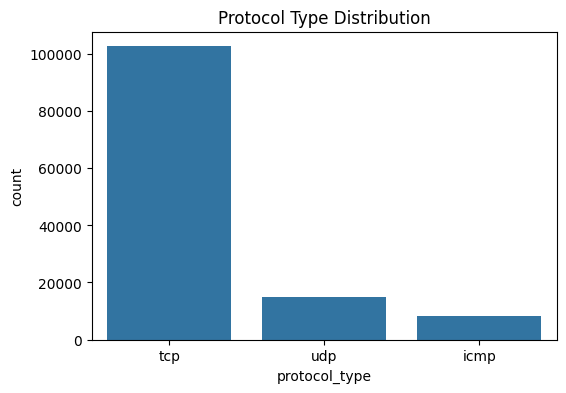

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='protocol_type', data=df_train)
plt.title('Protocol Type Distribution')
plt.show()


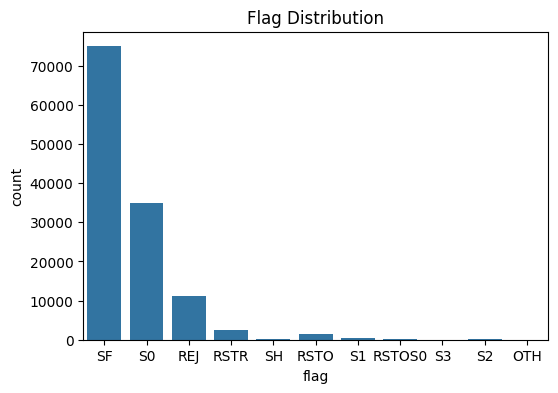

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='flag', data=df_train)
plt.title('Flag Distribution')
plt.show()


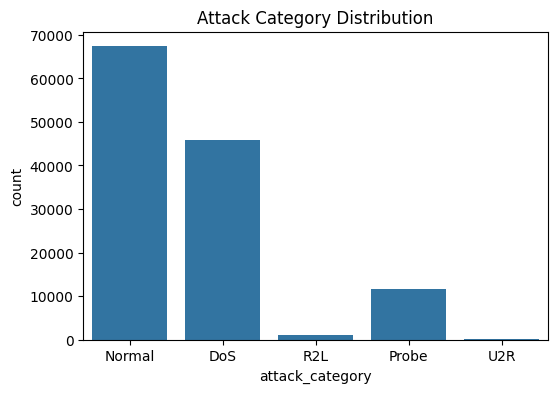

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='attack_category', data=df_train)
plt.title('Attack Category Distribution')
plt.show()


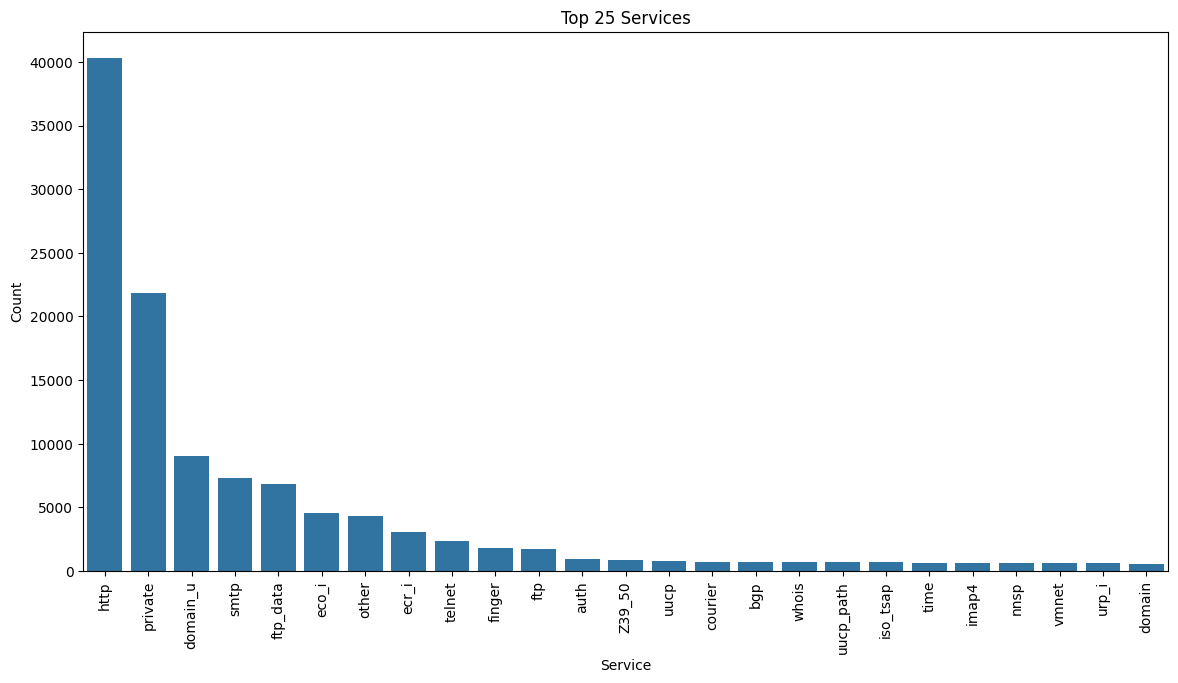

In [21]:
service_counts = df_train.iloc[:, 2].value_counts().head(25)

plt.figure(figsize=(14, 7))
sns.barplot(x=service_counts.index, y=service_counts.values)
plt.xticks(rotation=90)
plt.title("Top 25 Services")
plt.ylabel("Count")
plt.xlabel("Service")
plt.show()

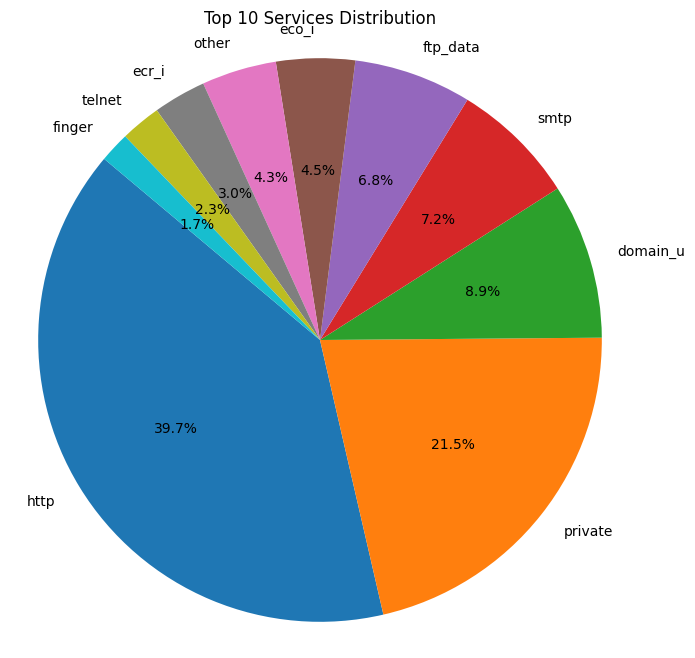

In [22]:
service_counts = df_train['service'].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    service_counts.values,
    labels=service_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top 10 Services Distribution")
plt.axis('equal')   # makes the pie perfectly circular
plt.show()


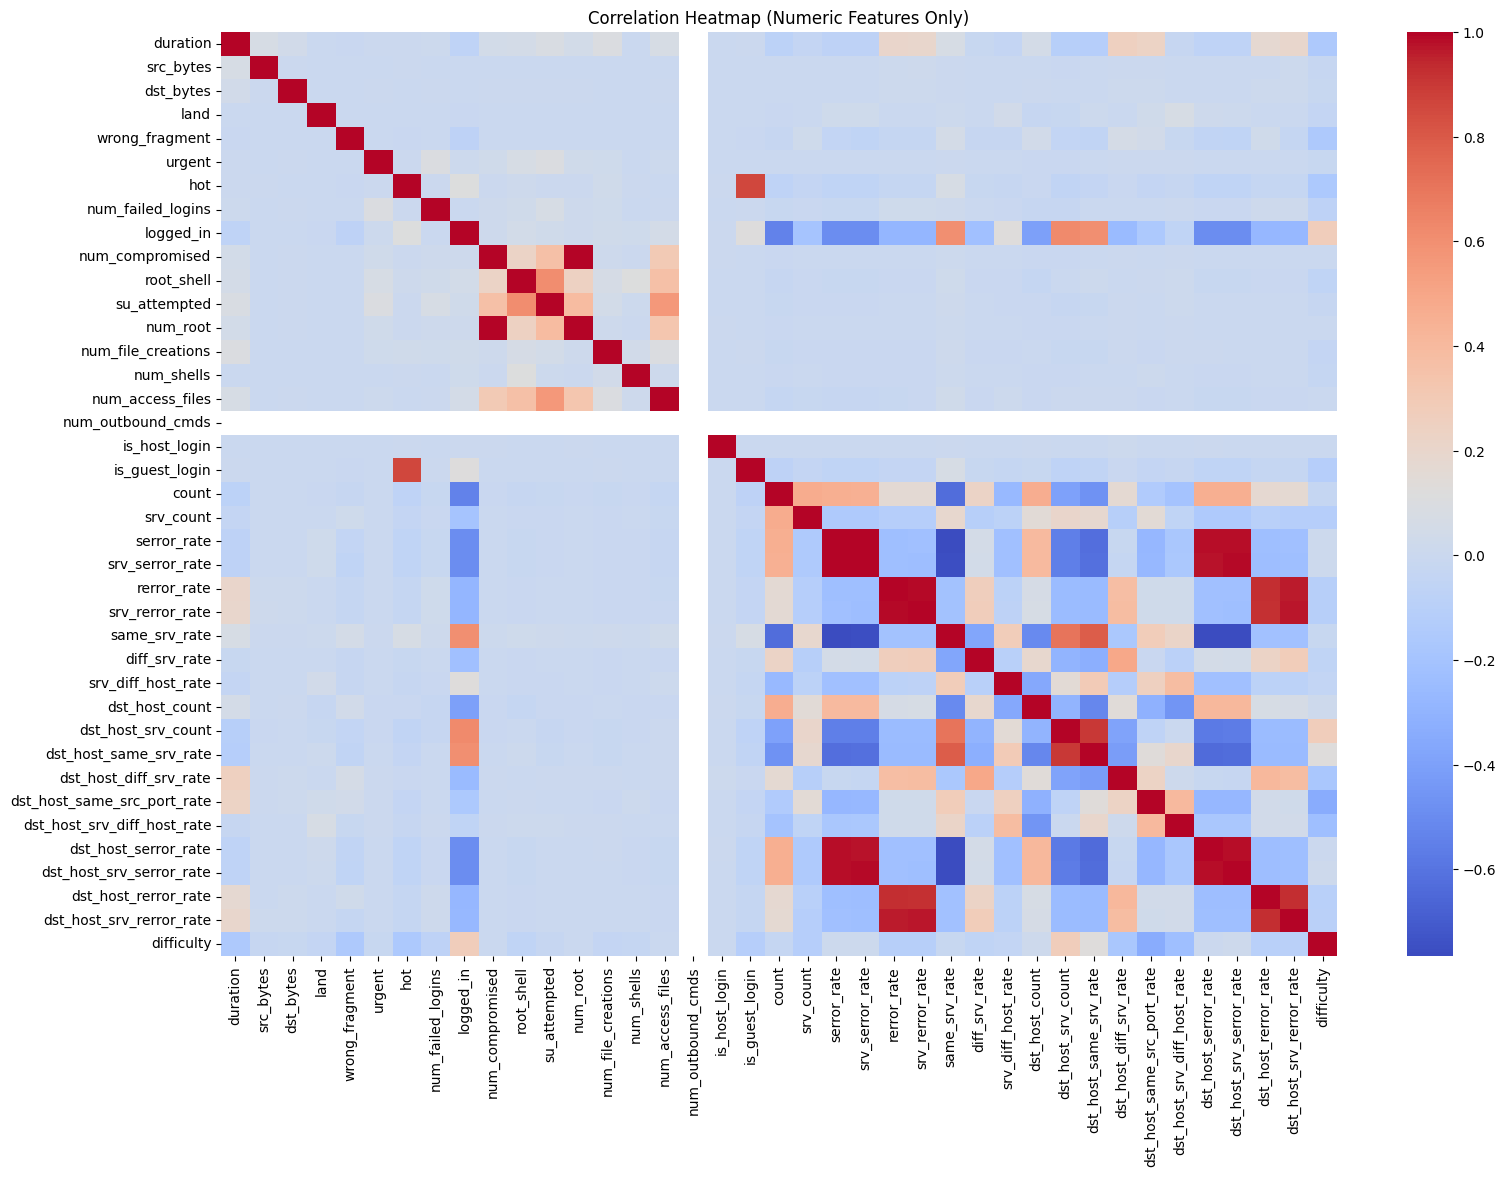

COLOR INTERPRETATION (coolwarm scale):
 Dark Red   : Strong Positive Correlation (+0.7 to +1.0)
 Light Red  : Moderate Positive Correlation (+0.3 to +0.7)
 White      : No Correlation (0)
 Light Blue : Moderate Negative Correlation (-0.3 to -0.7)
 Dark Blue : Strong Negative Correlation (-0.7 to -1.0)


In [23]:
numeric_df = df_train.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(18,12))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()
print("COLOR INTERPRETATION (coolwarm scale):")
print(" Dark Red   : Strong Positive Correlation (+0.7 to +1.0)")
print(" Light Red  : Moderate Positive Correlation (+0.3 to +0.7)")
print(" White      : No Correlation (0)")
print(" Light Blue : Moderate Negative Correlation (-0.3 to -0.7)")
print(" Dark Blue : Strong Negative Correlation (-0.7 to -1.0)")

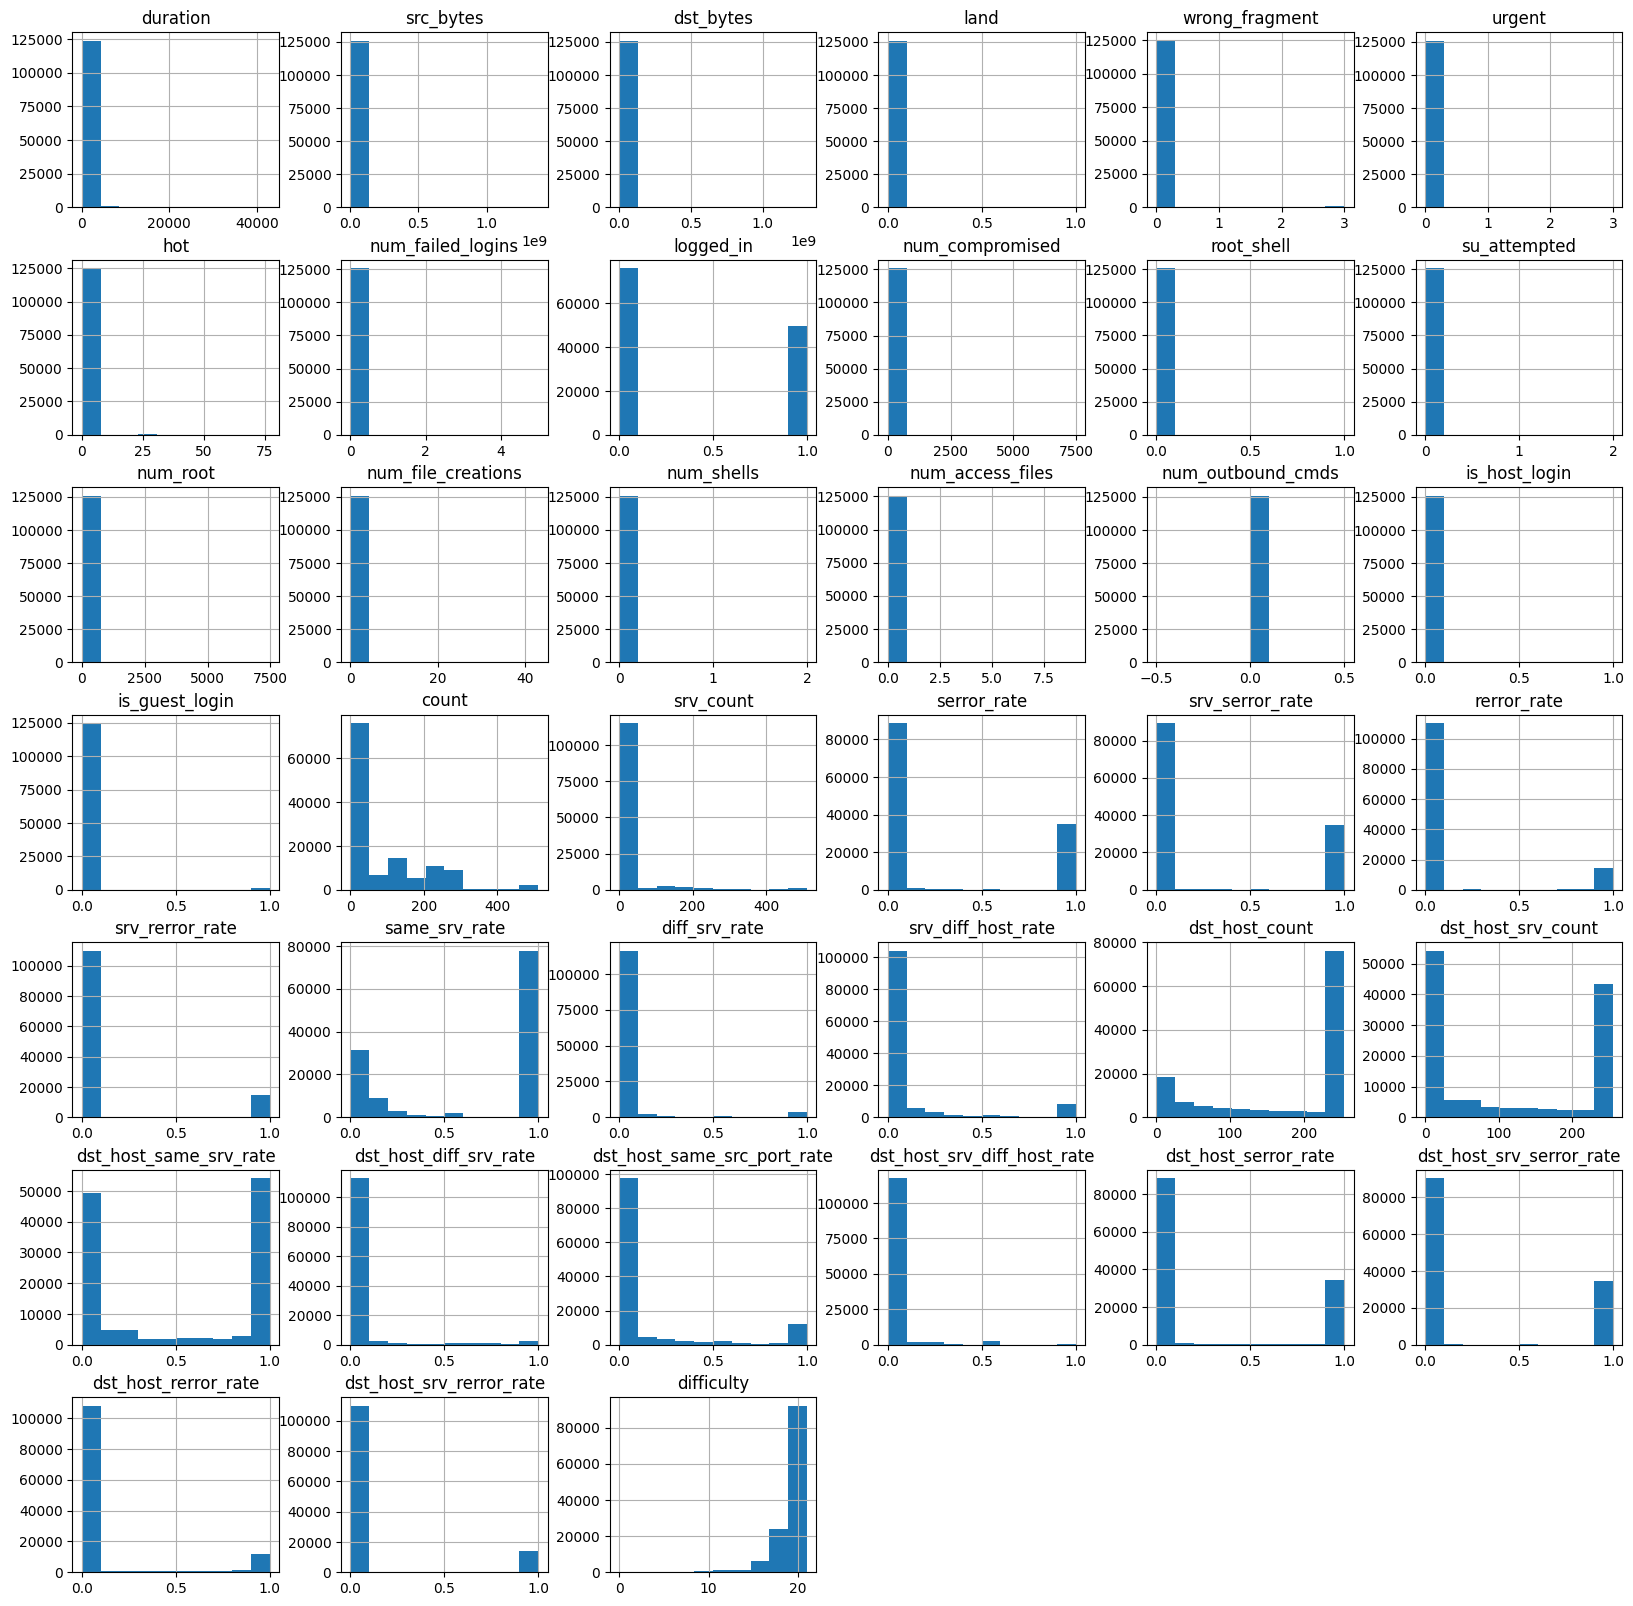

In [24]:
df_train.hist(figsize=(20,20))
plt.show()

In [25]:
scaler = StandardScaler()
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
df_train[numeric_cols] = scaler.fit_transform(df_train[numeric_cols])
df_train[numeric_cols].describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,...,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05
mean,2.549477e-17,-4.512349e-19,7.614590e-19,-4.794371e-18,4.230328e-19,4.455945e-18,-2.244894e-17,2.989431e-18,1.558171e-17,-6.549957e-18,...,-5.815290e-17,-1.215514e-16,-2.374624e-17,2.899184e-17,3.068398e-17,1.711873e-17,-2.631264e-17,4.907180e-17,7.749960e-17,-1.369921e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,...,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-1.102492e-01,-7.762241e-03,-4.918644e-03,-1.408881e-02,-8.948642e-02,-7.735985e-03,-9.507567e-02,-2.702282e-02,-8.092618e-01,-1.166364e-02,...,-1.044721e+00,-1.161030e+00,-4.390782e-01,-4.801968e-01,-2.891034e-01,-6.395319e-01,-6.248708e-01,-3.876346e-01,-3.763870e-01,-8.511505e+00
25%,-1.102492e-01,-7.762241e-03,-4.918644e-03,-1.408881e-02,-8.948642e-02,-7.735985e-03,-9.507567e-02,-2.702282e-02,-8.092618e-01,-1.166364e-02,...,-9.543885e-01,-1.049659e+00,-4.390782e-01,-4.801968e-01,-2.891034e-01,-6.395319e-01,-6.248708e-01,-3.876346e-01,-3.763870e-01,-6.563668e-01
50%,-1.102492e-01,-7.754745e-03,-4.918644e-03,-1.408881e-02,-8.948642e-02,-7.735985e-03,-9.507567e-02,-2.702282e-02,-8.092618e-01,-1.166364e-02,...,-4.756270e-01,-2.504011e-02,-3.332138e-01,-4.801968e-01,-2.891034e-01,-6.395319e-01,-6.248708e-01,-3.876346e-01,-3.763870e-01,2.164263e-01
75%,-1.102492e-01,-7.715224e-03,-4.790326e-03,-1.408881e-02,-8.948642e-02,-7.735985e-03,-9.507567e-02,-2.702282e-02,1.235694e+00,-1.166364e-02,...,1.258754e+00,1.066401e+00,-6.855302e-02,-2.860195e-01,-1.114257e-01,1.608759e+00,1.618955e+00,-3.876346e-01,-3.763870e-01,6.528229e-01
max,1.636428e+01,2.350675e+02,3.257486e+02,7.097831e+01,1.174348e+01,2.088191e+02,3.571955e+01,1.104972e+02,1.235694e+00,3.123689e+02,...,1.258754e+00,1.066401e+00,4.854138e+00,2.756092e+00,8.594782e+00,1.608759e+00,1.618955e+00,2.874410e+00,2.753914e+00,6.528229e-01


In [26]:
numeric_columns = df_train.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(df_train[numeric_columns])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_columns)
X_train_scaled.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.000000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,0.006692,3.302024e-05,1.509928e-05,0.000198,0.007562,0.000037,0.002655,0.000244,0.395736,0.000037,...,0.453541,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,0.928765
std,0.060700,4.253974e-03,3.069818e-03,0.014086,0.084510,0.004789,0.027922,0.009048,0.489010,0.003201,...,0.434128,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,0.109119
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.039216,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.857143
50%,0.000000,3.188489e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.247059,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.952381
75%,0.000000,2.000052e-07,3.939120e-07,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
df_train[['protocol_type', 'service', 'flag']].dtypes


,0
protocol_type,object
service,object
flag,object


In [28]:
categorical_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in categorical_cols:
    df_train[col] = le.fit_transform(df_train[col])
    df_train[categorical_cols].head()




In [29]:
df_train[['protocol_type', 'service', 'flag']].head()


,protocol_type,service,flag
0,1,20,9
1,2,44,9
2,1,49,5
3,1,24,9
4,1,24,9


In [30]:
X = df_train.drop(columns=['attack_category', 'attack_label'])
y = df_train['attack_category']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


In [32]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True))


Training data shape: (88181, 42)
Testing data shape: (37792, 42)

Class distribution in training set:
attack_category
Normal    0.534820
DoS       0.364580
Probe     0.092526
R2L       0.007904
U2R       0.000170
Name: proportion, dtype: float64

Class distribution in testing set:
attack_category
Normal    0.534822
DoS       0.364575
Probe     0.092533
R2L       0.007885
U2R       0.000185
Name: proportion, dtype: float64


In [33]:
stratify = y
y.value_counts()
y.value_counts(normalize=True) * 100


,proportion
attack_category,
Normal,53.482095
DoS,36.457812
Probe,9.252776
R2L,0.789852
U2R,0.017464


In [34]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
attack_category
Normal    0.534820
DoS       0.364580
Probe     0.092526
R2L       0.007904
U2R       0.000170
Name: proportion, dtype: float64

Test distribution:
attack_category
Normal    0.534822
DoS       0.364575
Probe     0.092533
R2L       0.007885
U2R       0.000185
Name: proportion, dtype: float64


In [35]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train, y_train
)

In [36]:
y_train_resampled.value_counts()


,count
attack_category,
Normal,47161
DoS,47161
Probe,47161
R2L,47161
U2R,47161


In [37]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1 Score:", rf_f1)


Random Forest Accuracy: 0.999417866215072
Random Forest Precision: 0.9994167926545605
Random Forest Recall: 0.999417866215072
Random Forest F1 Score: 0.9993571669802642


In [38]:
lr = LogisticRegression(
    max_iter=3000,
    solver='lbfgs'
)

lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)

lr_accuracy = accuracy_score(y_train, y_train_pred)
lr_precision = precision_score(y_train, y_train_pred, average='weighted')
lr_recall = recall_score(y_train, y_train_pred, average='weighted')
lr_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("Logistic Regression Training Accuracy:", lr_accuracy)
print("Logistic Regression Training Precision:", lr_precision)
print("Logistic Regression Training Recall:", lr_recall)
print("Logistic Regression Training F1 Score:", lr_f1)

Logistic Regression Training Accuracy: 0.9840555221646387
Logistic Regression Training Precision: 0.9840129668691872
Logistic Regression Training Recall: 0.9840555221646387
Logistic Regression Training F1 Score: 0.9840260707128584


In [39]:
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1 Score:", svm_f1)

SVM Accuracy: 0.9882514817950889
SVM Precision: 0.9883024283158284
SVM Recall: 0.9882514817950889
SVM F1 Score: 0.988211212777387


In [40]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Accuracy:", knn_accuracy)
print("KNN Precision:", knn_precision)
print("KNN Recall:", knn_recall)
print("KNN F1 Score:", knn_f1)

KNN Accuracy: 0.9980683742591024
KNN Precision: 0.9979942498058356
KNN Recall: 0.9980683742591024
KNN F1 Score: 0.9980232553702667


In [41]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)
print("Decision Tree F1 Score:", dt_f1)


Decision Tree Accuracy: 0.998174216765453
Decision Tree Precision: 0.9981438865175862
Decision Tree Recall: 0.998174216765453
Decision Tree F1 Score: 0.9981524938747115


In [42]:
evaluation_df = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest',
        'Logistic Regression',
        'SVM',
        'KNN'
    ],
    'Accuracy': [
        dt_accuracy,
        rf_accuracy,
        lr_accuracy,
        svm_accuracy,
        knn_accuracy
    ],
    'Precision': [
        dt_precision,
        rf_precision,
        lr_precision,
        svm_precision,
        knn_precision
    ],
    'Recall': [
        dt_recall,
        rf_recall,
        lr_recall,
        svm_recall,
        knn_recall
    ],
    'F1 Score': [
        dt_f1,
        rf_f1,
        lr_f1,
        svm_f1,
        knn_f1
    ]
})

evaluation_df



,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.998174,0.998144,0.998174,0.998152
1,Random Forest,0.999418,0.999417,0.999418,0.999357
2,Logistic Regression,0.984056,0.984013,0.984056,0.984026
3,SVM,0.988251,0.988302,0.988251,0.988211
4,KNN,0.998068,0.997994,0.998068,0.998023


In [43]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance', ascending=False
)

In [44]:
feature_importance.head(10)


,Feature,Importance
28,same_srv_rate,0.113508
4,src_bytes,0.110181
29,diff_srv_rate,0.081726
3,flag,0.069547
5,dst_bytes,0.054441
22,count,0.049574
38,dst_host_srv_serror_rate,0.045859
41,difficulty,0.045770
34,dst_host_diff_srv_rate,0.042823
24,serror_rate,0.040595


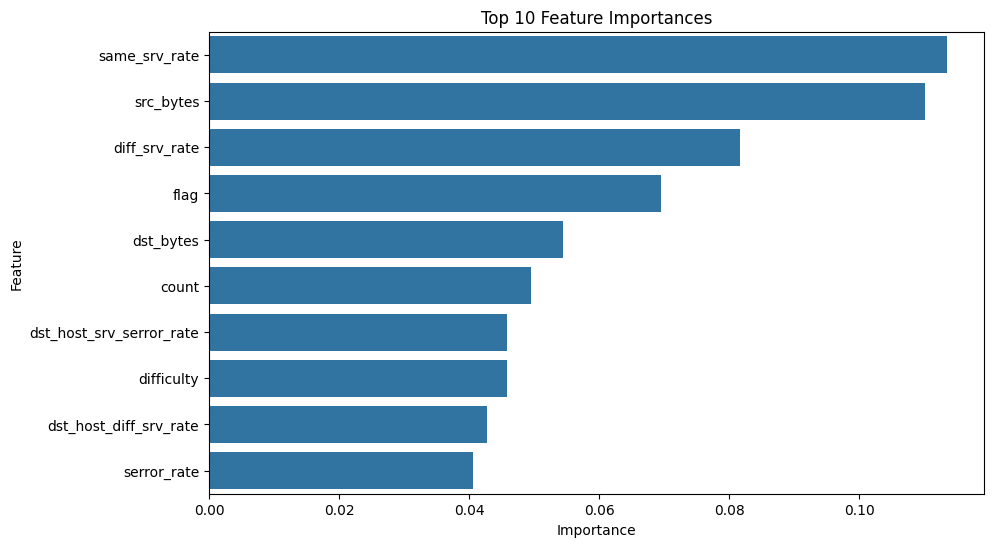

In [45]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Feature Importances')
plt.show()


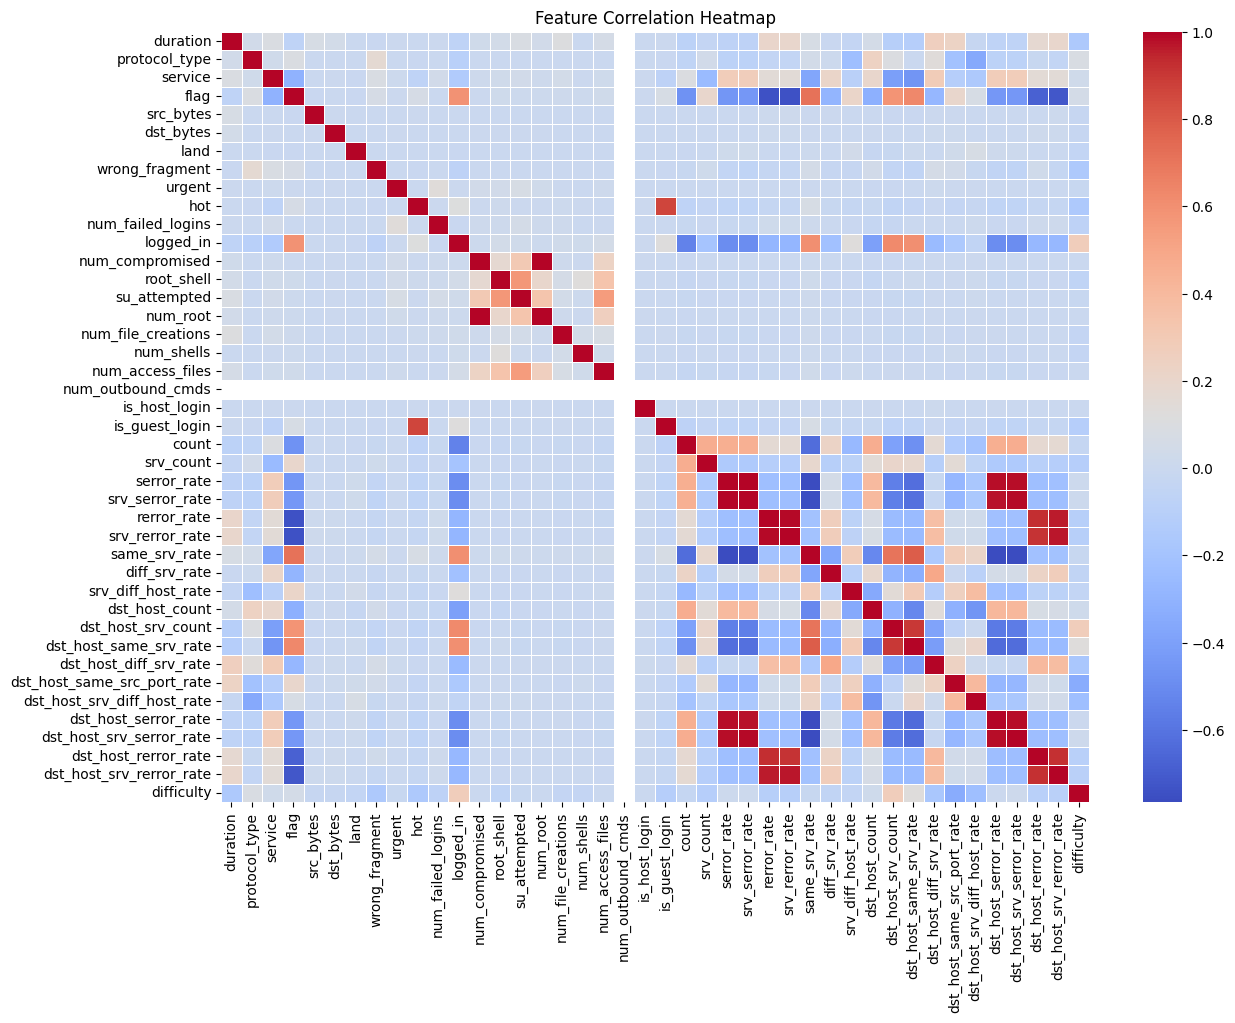

In [46]:
plt.figure(figsize=(14,10))
corr_matrix = X_train.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()


In [47]:
threshold = 0.90
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > threshold)
]

print("Highly correlated features:", to_drop)


Highly correlated features: ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [48]:
X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced  = X_test.drop(columns=to_drop)

print("Original features:", X_train.shape[1])
print("Reduced features:", X_train_reduced.shape[1])


Original features: 42
Reduced features: 35


In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_train.shape[1])
print("PCA components:", X_pca.shape[1])

Original features: 42
PCA components: 25


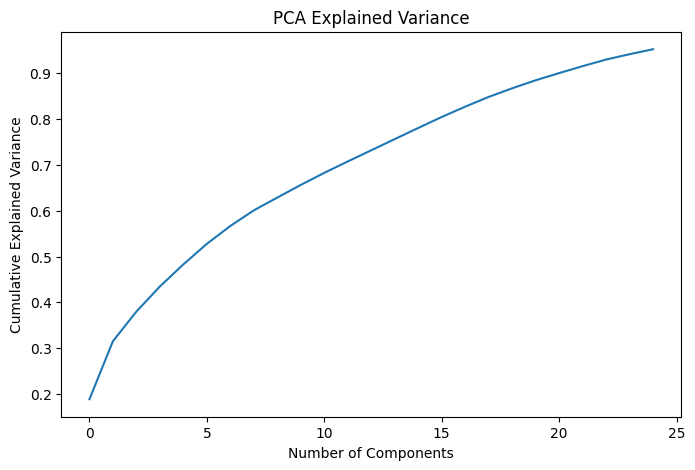

In [50]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


In [51]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

iso_forest.fit(X_train)
iso_pred = iso_forest.predict(X_test)
iso_pred = np.where(iso_pred == -1, 1, 0)

print("Isolation Forest Anomaly Detection Completed")


Isolation Forest Anomaly Detection Completed


In [52]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train)

kmeans_labels = kmeans.predict(X_test)

print("K-Means Clustering Completed")


K-Means Clustering Completed


In [53]:
iso_pred = iso_forest.predict(X_test)

# Convert output:
#  1  → Normal
# -1 → Anomaly
iso_pred = np.where(iso_pred == -1, 1, 0)

print("Traffic pattern deviation detection completed")


Traffic pattern deviation detection completed


In [54]:
normal_count = np.sum(iso_pred == 0)
anomaly_count = np.sum(iso_pred == 1)

print("Normal traffic samples :", normal_count)
print("Deviating traffic samples :", anomaly_count)


Normal traffic samples : 35928
Deviating traffic samples : 1864


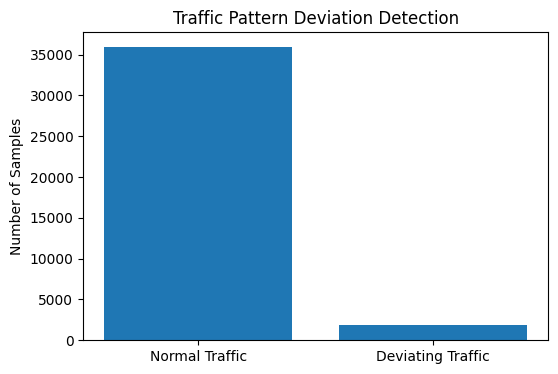

In [55]:


plt.figure(figsize=(6,4))
plt.bar(["Normal Traffic", "Deviating Traffic"],
        [normal_count, anomaly_count])

plt.title("Traffic Pattern Deviation Detection")
plt.ylabel("Number of Samples")
plt.show()


In [56]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)


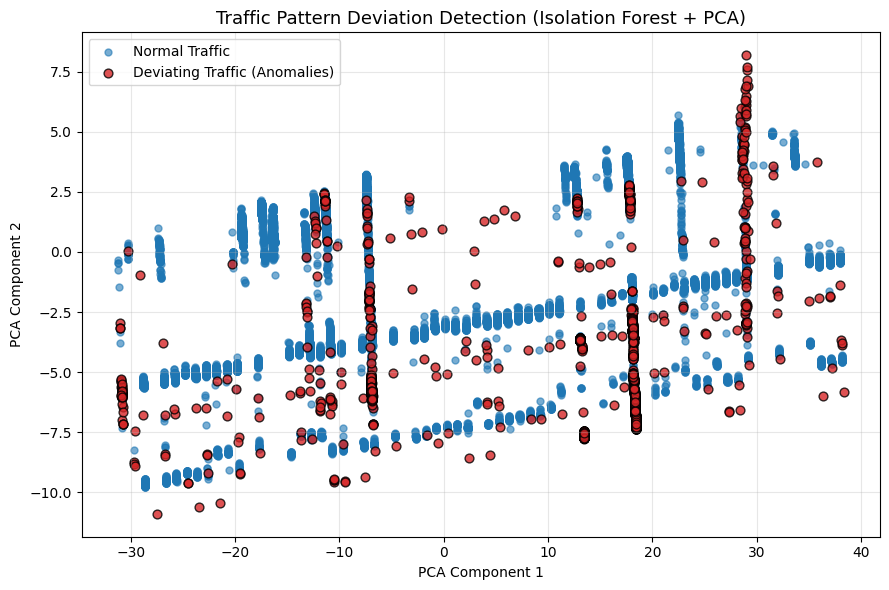

In [57]:
plt.figure(figsize=(9, 6))

# Normal traffic
plt.scatter(
    X_test_pca[iso_pred == 0, 0],
    X_test_pca[iso_pred == 0, 1],
    c='#1f77b4',        # Professional blue
    label='Normal Traffic',
    alpha=0.6,
    s=25
)

# Deviating traffic
plt.scatter(
    X_test_pca[iso_pred == 1, 0],
    X_test_pca[iso_pred == 1, 1],
    c='#d62728',        # Clear red
    label='Deviating Traffic (Anomalies)',
    alpha=0.8,
    s=40,
    edgecolors='black'
)

plt.title("Traffic Pattern Deviation Detection (Isolation Forest + PCA)",
          fontsize=13)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Scores: [0.99948971 0.99920617 0.99943298 0.99920617 0.99903606]
Mean CV Accuracy: 0.9992742176263423


In [59]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1_weighted"
)

grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 20, 'n_estimators': 100}

In [60]:
best_rf = grid.best_estimator_

best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)


In [61]:
final_model = grid.best_estimator_
final_model

RandomForestClassifier(max_depth=20, random_state=42)

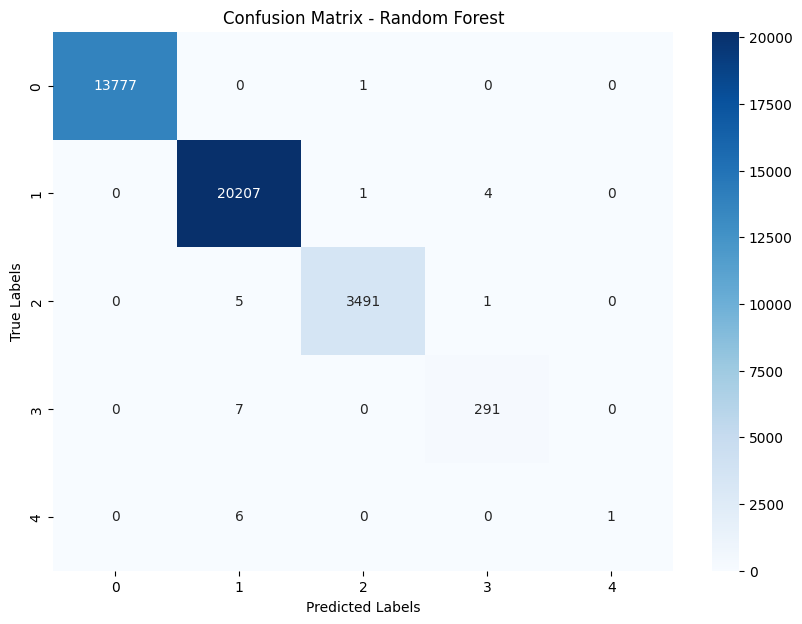

In [62]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [63]:
y_prob_rf = rf.predict_proba(X_test)


In [64]:
y_test_binary = np.where(y_test == 'Normal', 0, 1)
attack_class_index = list(rf.classes_).index('Normal')
y_prob_attack = 1 - y_prob_rf[:, attack_class_index]
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob_attack)
auc_score = roc_auc_score(y_test_binary, y_prob_attack)

print("ROC AUC Score:", auc_score)

ROC AUC Score: 0.999999123342625


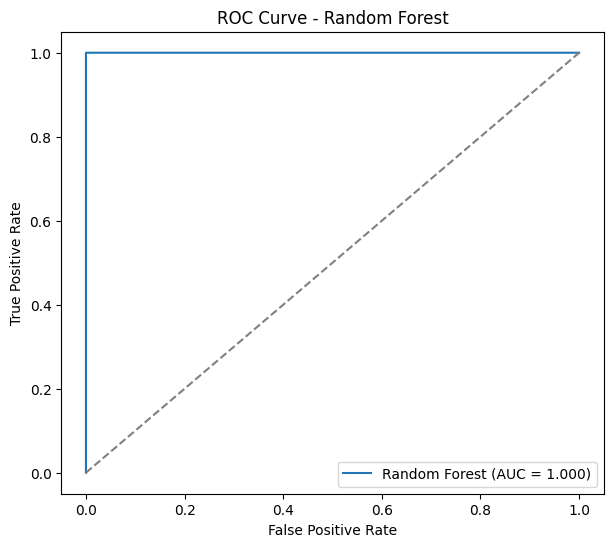

In [65]:
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [66]:
sample_data = X_test.sample(100, random_state=42)

predictions = best_rf.predict(sample_data)


In [67]:
alerts = []

for idx, pred in zip(sample_data.index, predictions):
    if pred != 'Normal':
        alerts.append({
            'Index': idx,
            'Alert': 'Intrusion Detected',
            'Attack_Type': pred
        })


In [68]:
alerts_df = pd.DataFrame(alerts)

alerts_df.head()

,Index,Alert,Attack_Type
0,26172,Intrusion Detected,DoS
1,44676,Intrusion Detected,DoS
2,645,Intrusion Detected,DoS
3,122837,Intrusion Detected,DoS
4,6662,Intrusion Detected,DoS


In [69]:
alerts_df.to_csv("intrusion_alerts.csv", index=False)

print("Alerts saved successfully!")


Alerts saved successfully!


In [70]:
alerts_df['Attack_Type'].value_counts()


,count
Attack_Type,
DoS,35
Probe,12
R2L,2


In [71]:
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [72]:
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")
joblib.dump(y_pred_rf, "y_pred_rf.pkl")
joblib.dump(iso_pred, "iso_pred.pkl")


['iso_pred.pkl']

In [73]:
!zip dashboard_files.zip \
random_forest_model.pkl \
X_test.pkl \
y_test.pkl \
y_pred_rf.pkl \
iso_pred.pkl


  adding: random_forest_model.pkl (deflated 79%)
  adding: X_test.pkl (deflated 93%)
  adding: y_test.pkl (deflated 67%)
  adding: y_pred_rf.pkl (deflated 86%)
  adding: iso_pred.pkl (deflated 99%)


In [74]:
from google.colab import files
files.download("dashboard_files.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>